# Insurance Charges Prediction Model using Polynomial Regression

In [122]:
#importing major libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [123]:
#reading the dataset
df=pd.read_csv('/content/insurance.csv')

In [124]:
#inspecting the first 5 records
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [125]:
#inspecting the shape of this dataset
print(f'This dataset contains {df.shape[0]} rows and {df.shape[1]} columns.')

This dataset contains 1338 rows and 7 columns.


In [126]:
#inspecting the basic structure and datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [127]:
#checking for duplicate records
print(f'Total Duplicate records:',df.duplicated().sum())

Total Duplicate records: 1


In [128]:
#dropping the duplicate record
df.drop_duplicates(inplace=True)

In [129]:
#checking for null values in a dataframe
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [130]:
#inspecting unique values in all the columns except bmi
df_cols= set(df.columns)
exclude={'bmi'}
df_cols=df_cols.difference(exclude)
for col in df_cols:
  print(f'{col}:\n', df[col].unique())

region:
 ['southwest' 'southeast' 'northwest' 'northeast']
charges:
 [16884.924   1725.5523  4449.462  ...  1629.8335  2007.945  29141.3603]
children:
 [0 1 3 2 5 4]
smoker:
 ['yes' 'no']
age:
 [19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]
sex:
 ['female' 'male']


## Feature Engineering

In [131]:
#setting the color palette
sns.set_palette('rocket')

In [132]:
#bmi category
bmi_bins = [0, 18.5, 25, 30, np.inf]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']

df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=bmi_bins,
    labels=bmi_labels,
    right=False )

In [133]:
#age group
age_bins = [0, 18, 30, 45, 60, np.inf]
age_labels = ['<18', '18-29', '30-44', '45-59', '60+']

df['age_group'] = pd.cut(
    df['age'],
    bins=age_bins,
    labels=age_labels,
    right=False
)

In [134]:
#rechecking the dataframe
df.head(5)

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight,18-29
1,18,male,33.770,1,no,southeast,1725.55230,Obese,18-29
2,28,male,33.000,3,no,southeast,4449.46200,Obese,18-29
3,33,male,22.705,0,no,northwest,21984.47061,Normal,30-44
4,32,male,28.880,0,no,northwest,3866.85520,Overweight,30-44


### Insights
- BMI is binned into Underweight, Normal, Overweight and Obese (WHO cut-offs), and age into groups.
- `age_group` is used for EDA only and dropped before modelling.
- About **53% of people are Obese** (706 of 1,337), and only **20 are Underweight**, so that category is too small to give stable estimates.

## Univariate Analysis

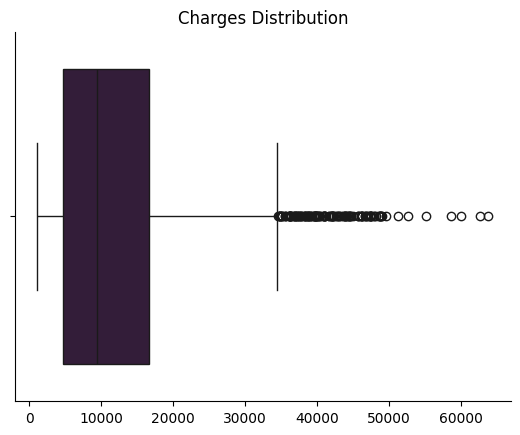

In [135]:
#charges(outlier detection)
sns.boxplot(data=df,x='charges')
plt.title('Charges Distribution')
plt.xlabel('')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

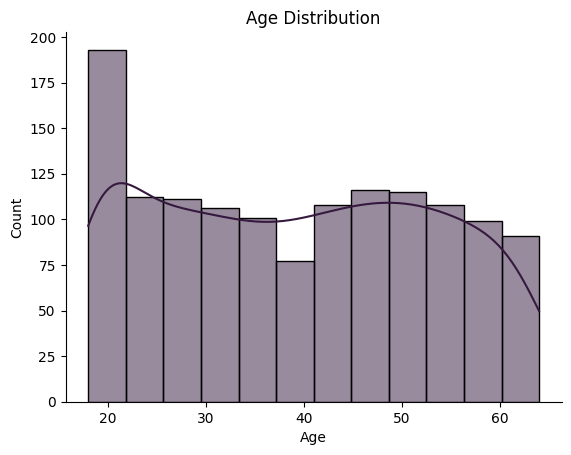

In [136]:
#age
sns.histplot(data=df,x='age', kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

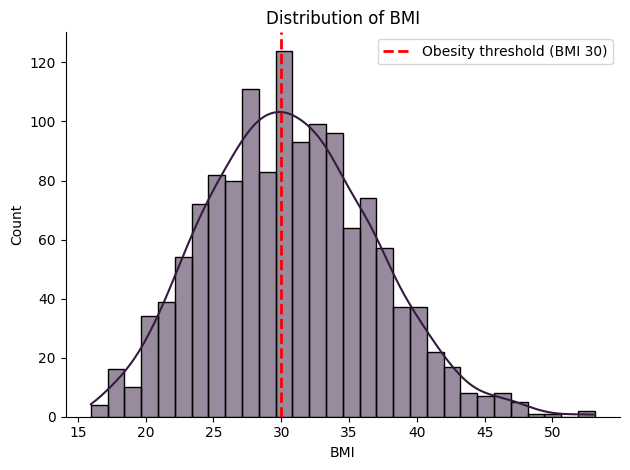

In [137]:
# BMI with obesity threshold
sns.histplot(df['bmi'], bins=30, kde=True)
plt.axvline(30, color='red', linestyle='--', linewidth=2, label='Obesity threshold (BMI 30)')
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.legend()

plt.tight_layout()
plt.show()

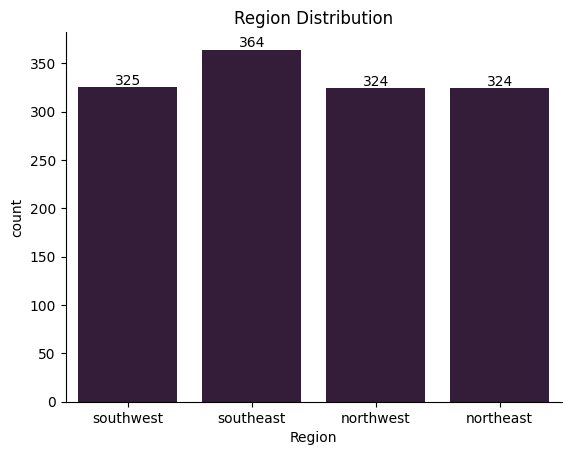

In [138]:
#region distribution
ax=sns.countplot(data=df,x='region')
plt.title('Region Distribution')
plt.xlabel('Region')
for p in ax.patches:
  ax.text(p.get_x()+p.get_width() / 2, p.get_height(),s=f'{int(p.get_height())}',ha='center', va='bottom')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

### Insights
- **Charges** are strongly right-skewed (mean about 13,279, maximum about 63,770), with about **139 high-end outliers** by the IQR rule.
- **Age** is roughly uniform from 18 to 64, with a spike at the youngest ages.
- **BMI** is roughly normal with a mean of about 30.7, right at the obesity threshold.
- **Region** is almost perfectly balanced (324 to 364 per region), so there is no regional sampling bias.
- Sex is balanced (675 male, 662 female). Smokers are a minority (274, about 20%)

## Bivariate Analysis

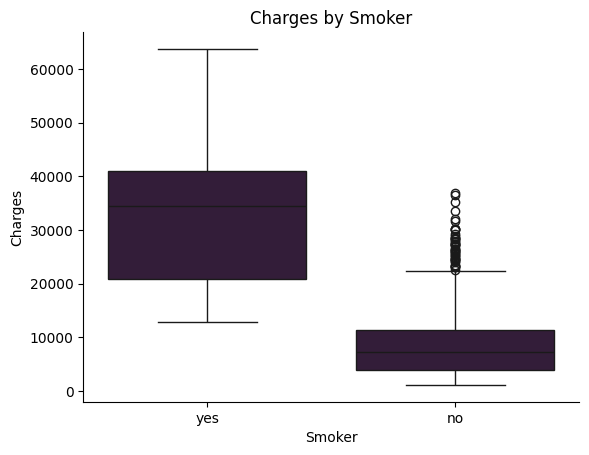

In [139]:
#charges by smoker
sns.boxplot(data=df, x='smoker', y='charges')
plt.title('Charges by Smoker')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

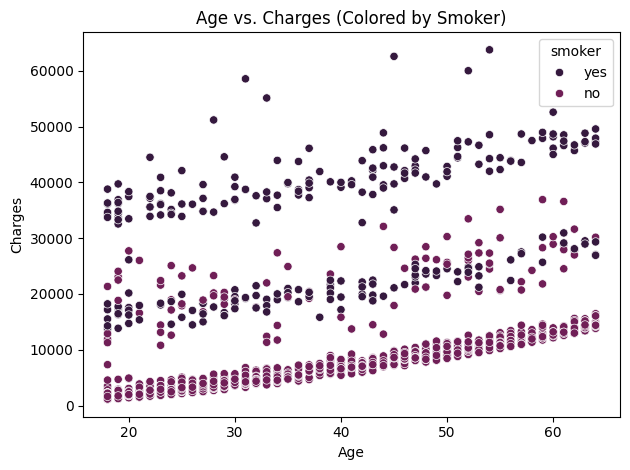

In [140]:
#age vs charges colured by smoker
sns.scatterplot(data=df, x='age', y='charges', hue='smoker')
plt.title('Age vs. Charges (Colored by Smoker)')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.tight_layout()
plt.show()

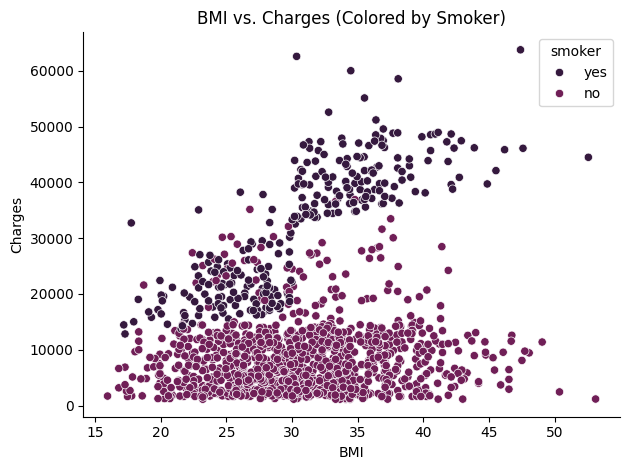

In [141]:
#bmi vs charges colored by smoker
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker')
plt.title('BMI vs. Charges (Colored by Smoker)')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.tight_layout()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

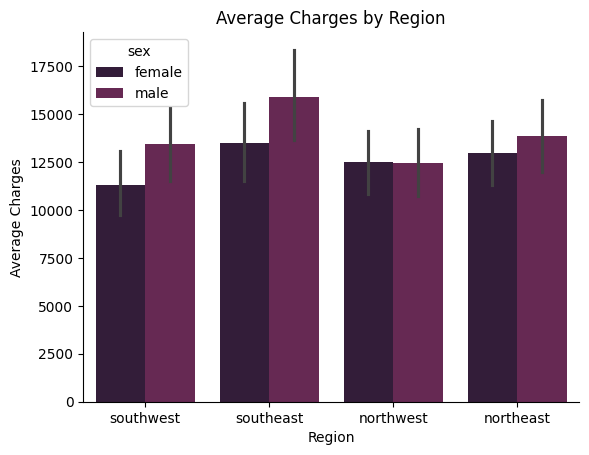

In [142]:
#bar charts of average charges by region, sex and number of children.
sns.barplot(data=df, x='region', y='charges', estimator=np.mean,hue='sex')
plt.title('Average Charges by Region')
plt.xlabel('Region')
plt.ylabel('Average Charges')
plt.gca().spines[['top', 'right']].set_visible(False)

### Insights
- **Smoking is the dominant driver.** Smokers pay about **32,050** on average against about **8,441** for non-smokers, nearly 4 times more. Correlation of smoker with charges is **0.79**.
- **Age drives cost in both groups.** Charges rise with age for non-smokers (correlation 0.63) and smokers (0.37).
- **BMI interacts with smoking.** Among non-smokers BMI barely matters (about 8.9k for Obese vs 7.7k for Normal). Among smokers, **Obese smokers average about 41.6k vs about 22.5k for Overweight smokers**.
- **Region and sex have small effects.** Southeast is highest (about 14.7k), southwest lowest (about 12.3k). Males average about 14.0k vs about 12.6k for females.
- **Children:** charges rise up to 3 children (about 15.4k), then drop. The 4 and 5 children groups have only 25 and 18 people, so that drop is unreliable.

## Feature Encoding

In [143]:
df.head(5)

,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight,18-29
1,18,male,33.770,1,no,southeast,1725.55230,Obese,18-29
2,28,male,33.000,3,no,southeast,4449.46200,Obese,18-29
3,33,male,22.705,0,no,northwest,21984.47061,Normal,30-44
4,32,male,28.880,0,no,northwest,3866.85520,Overweight,30-44


In [144]:
#copying the data
df_encoded = df.copy()

#mapping sex and smoker column with 0 and 1
df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})

#applying dummy encoding on bmi and region column
df_encoded = pd.get_dummies(df_encoded, columns=['region', 'bmi_category'], dtype=int, drop_first=True)

In [145]:
#dropping age_group column as age is already present
df_encoded=df_encoded.drop('age_group',axis=1)

In [146]:
#rechecking the dataframe
df_encoded.head(5)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,0,27.900,0,1,16884.92400,0,0,1,0,1,0
1,18,1,33.770,1,0,1725.55230,0,1,0,0,0,1
2,28,1,33.000,3,0,4449.46200,0,1,0,0,0,1
3,33,1,22.705,0,0,21984.47061,1,0,0,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0,0,1,0


In [147]:
#importing major libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [148]:
#defining feature and target variable
x=df_encoded.drop('charges',axis=1)
y=df_encoded['charges']

In [149]:
#splitting dataset into train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [150]:
#standardisation
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [151]:
#fittiing linear model
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [152]:
#transforming features
poly=PolynomialFeatures(degree=2)
x_train_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

In [153]:
#performing linear regression of transformed features
lr_poly=LinearRegression()
lr_poly.fit(x_train_poly,y_train)

LinearRegression()

In [154]:
#prediction
y_pred=lr_poly.predict(x_test_poly)


In [155]:
#evaluation metrics
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [156]:
#displaying evaluation results
print(f'Model Coef: {lr_poly.coef_}')
print(f'Intercept: {lr_poly.intercept_}')
print(f'Mean Squared Error: {mse}')
print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {r2}')

Model Coef: [-2.78706079e-12  3.53375749e+03 -2.83572585e+02  1.02077994e+03
  9.88212642e+02  2.87742404e+03 -3.57314507e+01 -4.90255733e+01
 -1.63175177e+02  5.65931147e+02  6.65242749e+02  3.65479018e+03
  8.46188007e+02 -2.98609008e+01 -5.28569224e+01 -1.00674387e+02
 -1.01111089e+02  1.30976288e+02  4.22696687e+02  2.97000566e+02
 -7.14992062e+02 -6.80930323e+02 -8.50019264e+02  1.64535991e+01
  2.90103321e+02 -1.05938866e+02  4.67502562e+01  2.70906252e+02
  7.14635200e+01  1.66024186e+02 -2.46302448e+02 -2.99009830e+02
 -5.38256359e+02 -1.22606890e+01  2.24529558e+02  1.20664101e+03
 -3.92813753e+02 -1.02020405e+03 -3.12032701e+02  3.09008876e+03
  2.85722440e+03  3.04488312e+03 -1.68404974e+02 -1.90700460e+02
  3.06259639e+01 -2.26135428e+02 -2.68380650e+02 -1.38613364e+02
  5.70718036e+01 -6.81452678e+01  4.31193250e+03 -8.92375061e+01
 -3.07784661e+01 -1.71637989e+01 -3.58153917e+02 -2.87087523e+02
  2.55994091e+03 -4.19322350e+01  4.97219753e+01  1.13959214e+02
 -1.17507592e

In [157]:
#comparing actual vs predicted result
results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results_df

,Actual,Predicted
900,8688.85885,9406.198182
1064,5708.86700,6773.888299
1256,11436.73815,13901.982704
298,38746.35510,40177.124513
237,4463.20510,5823.038597
...,...,...
534,13831.11520,15338.758091
542,13887.20400,16362.542241
760,3925.75820,8073.633670
1284,47403.88000,47682.095295


In [161]:
#comparing linear, degree 2 and degree 3 models
comparison = []
for deg in [1, 2, 3]:
    p = PolynomialFeatures(degree=deg)
    xtr = p.fit_transform(x_train)
    xte = p.transform(x_test)
    m = LinearRegression().fit(xtr, y_train)
    pred = m.predict(xte)
    comparison.append({
        'Degree': deg,
        'Features': xtr.shape[1],
        'Train R2': r2_score(y_train, m.predict(xtr)),
        'Test R2': r2_score(y_test, pred),
        'Test MAE': mean_absolute_error(y_test, pred),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, pred))
    })
pd.DataFrame(comparison).round(3)

,Degree,Features,Train R2,Test R2,Test MAE,Test RMSE
0,1,12,0.738,0.803,4334.481,6023.856
1,2,78,0.862,0.902,2394.833,4237.946
2,3,364,0.878,0.874,2963.227,4803.374


In [163]:
#training vs testing score using polynomial transformed features to avoid shape mismatch
print(f'Train R2: {lr_poly.score(x_train_poly, y_train):.4f}')
print(f'Test  R2: {lr_poly.score(x_test_poly, y_test):.4f}')

Train R2: 0.8624
Test  R2: 0.9023


### Insights
| Model | Test R² | Test MAE | Test RMSE |
|---|---|---|---|
| Linear (degree 1) | 0.803 | 4,334 | 6,024 |
| **Polynomial (degree 2)** | **0.902** | **2,395** | **4,238** |
| Polynomial (degree 3) | 0.874 | 2,963 | 4,803 |

- **Degree 2 is the best choice.** It lifts test R² from 0.80 to 0.90 and cuts MAE by about 45%.
- **Degree 3 overfits.** Train R² goes up (0.862 to 0.878) while test R² falls, and it uses 364 features on about 1,070 training rows.